# Pipeline ML — Cohérence Texte-Image via Annotations COCO
## Stratégie
Utiliser les **annotations COCO** (objets détectés par image) pour mesurer
la relation texte-image **sans deep learning** :
- Caption mentionne-t-elle les objets présents dans l'image ?
- Overlap caption ↔ catégories COCO = signal cross-modal classique


In [1]:
# Cell 1 — Imports
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.utils import shuffle
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4',
                 'averaged_perceptron_tagger_eng', 'vader_lexicon', 'punkt_tab']:
    nltk.download(resource, quiet=True)

lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()
STOP = set(stopwords.words('english'))

print("Tous les imports OK.")


Tous les imports OK.


In [2]:
# Cell 2 — Chargement des données (avec chemins images)
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                       np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print("Chargement des splits...")
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f"Train: {len(t_train)} | Val: {len(t_val)} | Test: {len(t_test)}")
print(f"Balance train: {np.bincount(y_train)}")
print(f"\nExemple cohérent   : {t_train[y_train==1][0]}")
print(f"Exemple incohérent  : {t_train[y_train==0][0]}")


Chargement des splits...
Train: 7000 | Val: 1500 | Test: 1500
Balance train: [3505 3495]

Exemple cohérent   : A woman slashing down a snowy hill on skis.
Exemple incohérent  : A wall covered in graffiti next to a sidewalk.


In [3]:
# Cell 3 — Chargement annotations COCO
COCO_TRAIN = '../data/raw/annotations/instances_train2017.json'
COCO_VAL   = '../data/raw/annotations/instances_val2017.json'
print("Chargement instances_train2017.json...")
with open(COCO_TRAIN) as f:
    coco_train = json.load(f)

print("Chargement instances_val2017.json...")
with open(COCO_VAL) as f:
    coco_val = json.load(f)

def build_img2cats(coco_data):
    cat_map = {c['id']: c['name'] for c in coco_data['categories']}
    img2cats = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        cat    = cat_map[ann['category_id']]
        img2cats.setdefault(img_id, set()).add(cat)
    return img2cats

img2cats_train = build_img2cats(coco_train)
img2cats_val   = build_img2cats(coco_val)
# Fusionner les deux pour couvrir tous les splits
img2cats_all = {**img2cats_train, **img2cats_val}

print(f"Images indexées (train): {len(img2cats_train)}")
print(f"Images indexées (val)  : {len(img2cats_val)}")

# Vérification sur un exemple
sample_id = list(img2cats_train.keys())[0]
print(f"\nExemple image_id={sample_id}: {img2cats_train[sample_id]}")

# Toutes les catégories COCO disponibles
all_cats = sorted({c['name'] for c in coco_train['categories']})
print(f"\n{len(all_cats)} catégories COCO: {all_cats}")


Chargement instances_train2017.json...
Chargement instances_val2017.json...
Images indexées (train): 117266
Images indexées (val)  : 4952

Exemple image_id=558840: {'hot dog', 'dining table', 'cup', 'bottle', 'spoon', 'person'}

80 catégories COCO: ['airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed', 'bench', 'bicycle', 'bird', 'boat', 'book', 'bottle', 'bowl', 'broccoli', 'bus', 'cake', 'car', 'carrot', 'cat', 'cell phone', 'chair', 'clock', 'couch', 'cow', 'cup', 'dining table', 'dog', 'donut', 'elephant', 'fire hydrant', 'fork', 'frisbee', 'giraffe', 'hair drier', 'handbag', 'horse', 'hot dog', 'keyboard', 'kite', 'knife', 'laptop', 'microwave', 'motorcycle', 'mouse', 'orange', 'oven', 'parking meter', 'person', 'pizza', 'potted plant', 'refrigerator', 'remote', 'sandwich', 'scissors', 'sheep', 'sink', 'skateboard', 'skis', 'snowboard', 'spoon', 'sports ball', 'stop sign', 'suitcase', 'surfboard', 'teddy bear', 'tennis racket', 'tie', 'toaster

In [4]:
# Cell 4 — Features cross-modales (overlap caption ↔ objets COCO)
def get_image_id(filepath):
    basename = os.path.basename(filepath).replace('.txt','').replace('.jpg','')
    try:
        return int(basename)
    except:
        return None

def extract_crossmodal_features(text, img_path):
    img_id   = get_image_id(img_path)
    img_cats = img2cats_all.get(img_id, set())

    # Lemmatiser les tokens de la caption
    tokens   = word_tokenize(text.lower())
    lemmas   = set(lemmatizer.lemmatize(t) for t in tokens if t.isalpha())

    # Lemmatiser les catégories COCO (ex: "hot dog" → {"hot","dog"})
    coco_lemmas = set()
    for cat in img_cats:
        for w in cat.lower().split():
            coco_lemmas.add(lemmatizer.lemmatize(w))

    n_coco      = len(img_cats)
    n_words     = len(lemmas)
    overlap     = len(lemmas & coco_lemmas)
    precision   = overlap / (n_words  + 1e-8)
    recall      = overlap / (n_coco   + 1e-8)
    f1          = 2 * precision * recall / (precision + recall + 1e-8)
    any_overlap = int(overlap > 0)

    # Feature supplémentaire : ratio de mots de caption qui sont des catégories COCO
    caption_coco_ratio = len(lemmas & set(lemmatizer.lemmatize(c) 
                             for c in all_cats)) / (n_words + 1e-8)

    return np.array([
        n_coco, n_words, overlap,
        precision, recall, f1, any_overlap,
        caption_coco_ratio
    ])

CROSS_NAMES = [
    'n_coco_cats', 'n_caption_words', 'overlap',
    'precision', 'recall', 'f1_overlap', 'any_overlap',
    'caption_coco_ratio'
]

print("Extraction features cross-modales...")
C_train = np.array([extract_crossmodal_features(t, p) 
                    for t, p in zip(t_train, p_train)])
C_val   = np.array([extract_crossmodal_features(t, p) 
                    for t, p in zip(t_val,   p_val)])
C_test  = np.array([extract_crossmodal_features(t, p) 
                    for t, p in zip(t_test,  p_test)])

print(f"Shape features cross-modales: {C_train.shape}")
print(f"\nMoyenne overlap cohérent   : {C_train[y_train==1, 2].mean():.3f}")
print(f"Moyenne overlap incohérent  : {C_train[y_train==0, 2].mean():.3f}")
print("→ Si différence notable : signal détecté !")


Extraction features cross-modales...
Shape features cross-modales: (7000, 8)

Moyenne overlap cohérent   : 0.950
Moyenne overlap incohérent  : 0.058
→ Si différence notable : signal détecté !


In [5]:
# Cell 5 — Features linguistiques du texte
VISUAL_NOUNS = set(all_cats)  # utiliser directement les 80 catégories COCO

def extract_linguistic_features(text):
    tokens       = word_tokenize(text.lower())
    alpha_tokens = [t for t in tokens if t.isalpha()]
    tagged       = pos_tag(alpha_tokens)

    nouns   = [w for w, t in tagged if t.startswith('NN')]
    verbs   = [w for w, t in tagged if t.startswith('VB')]
    adjs    = [w for w, t in tagged if t.startswith('JJ')]
    content = [w for w in alpha_tokens if w not in STOP]

    sentiment = sia.polarity_scores(text)

    n_tokens  = len(alpha_tokens)
    n_nouns   = len(nouns)
    n_verbs   = len(verbs)
    n_adjs    = len(adjs)

    noun_ratio  = n_nouns / (n_tokens + 1)
    verb_ratio  = n_verbs / (n_tokens + 1)
    adj_ratio   = n_adjs  / (n_tokens + 1)
    noun_verb_r = n_nouns / (n_verbs  + 1)

    visual_hits  = sum(1 for w in nouns if lemmatizer.lemmatize(w) in VISUAL_NOUNS)
    visual_ratio = visual_hits / (n_nouns + 1)
    unique_ratio = len(set(alpha_tokens)) / (n_tokens + 1)
    avg_word_len = np.mean([len(w) for w in alpha_tokens]) if alpha_tokens else 0

    has_article    = int(any(t in ['a','an','the'] for t in tokens))
    starts_capital = int(text[0].isupper() if text else 0)
    ends_period    = int(text.strip().endswith('.'))

    return np.array([
        n_tokens, n_nouns, n_verbs, n_adjs, len(content),
        noun_ratio, verb_ratio, adj_ratio, noun_verb_r,
        visual_hits, visual_ratio, unique_ratio,
        has_article, starts_capital, ends_period, avg_word_len,
        sentiment['pos'], sentiment['neg'], sentiment['neu'], sentiment['compound']
    ])

LING_NAMES = [
    'n_tokens','n_nouns','n_verbs','n_adjs','n_content',
    'noun_ratio','verb_ratio','adj_ratio','noun_verb_ratio',
    'visual_hits','visual_ratio','unique_ratio',
    'has_article','starts_capital','ends_period','avg_word_len',
    'sentiment_pos','sentiment_neg','sentiment_neu','sentiment_compound'
]

print("Extraction features linguistiques...")
L_train = np.array([extract_linguistic_features(t) for t in t_train])
L_val   = np.array([extract_linguistic_features(t) for t in t_val])
L_test  = np.array([extract_linguistic_features(t) for t in t_test])
print(f"Shape features linguistiques: {L_train.shape}")


Extraction features linguistiques...
Shape features linguistiques: (7000, 20)


In [6]:
# Cell 6 — TF-IDF
print("Extraction TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=3
)
T_train = tfidf.fit_transform(t_train).toarray()
T_val   = tfidf.transform(t_val).toarray()
T_test  = tfidf.transform(t_test).toarray()
print(f"Shape TF-IDF: {T_train.shape}")

# ── Assemblage final ──────────────────────────────────────────────────────────
X_train_raw = np.hstack([C_train, L_train, T_train])
X_val_raw   = np.hstack([C_val,   L_val,   T_val])
X_test_raw  = np.hstack([C_test,  L_test,  T_test])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\nShape finale — Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Composition: {len(CROSS_NAMES)} cross-modal + {len(LING_NAMES)} linguistique + {T_train.shape[1]} TF-IDF")


Extraction TF-IDF...
Shape TF-IDF: (7000, 3000)

Shape finale — Train: (7000, 3028) | Val: (1500, 3028) | Test: (1500, 3028)
Composition: 8 cross-modal + 20 linguistique + 3000 TF-IDF


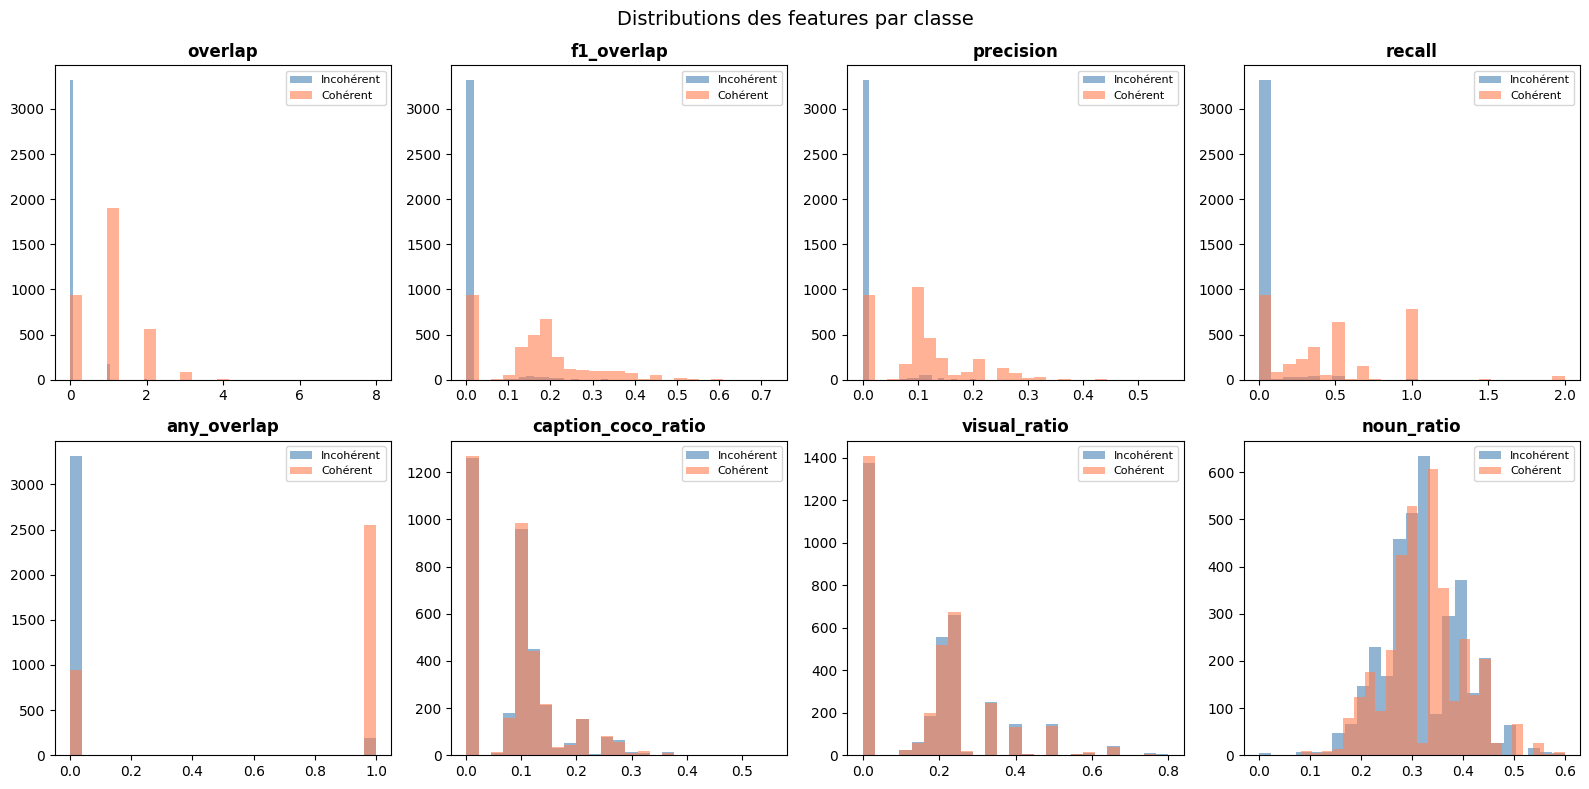

Features séparées = signal détecté !


In [7]:
# Cell 7 — Visualisation du signal cross-modal
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

all_feat_names = CROSS_NAMES + LING_NAMES
all_feats      = np.hstack([C_train, L_train])

key_features = ['overlap','f1_overlap','precision','recall',
                'any_overlap','caption_coco_ratio','visual_ratio','noun_ratio']

for i, name in enumerate(key_features):
    idx = all_feat_names.index(name)
    axes[i].hist(all_feats[y_train==0, idx], bins=25, alpha=0.6,
                 label='Incohérent', color='steelblue')
    axes[i].hist(all_feats[y_train==1, idx], bins=25, alpha=0.6,
                 label='Cohérent',   color='coral')
    axes[i].set_title(name, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions des features par classe', fontsize=14)
plt.tight_layout()
plt.show()
print("Features séparées = signal détecté !")


In [8]:
# Cell 8 — Entraînement (sans parallélisme)
models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=10, 
                       min_samples_leaf=2, random_state=42)
}

results = {}
print(f"{'Modèle':<25} {'CV moyen':>10} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 65)
for name, model in models.items():
    print(f"  Training {name}...", end=' ', flush=True)
    cv = cross_val_score(model, X_train, y_train, cv=3,  # cv=3 au lieu de 5
                         scoring='accuracy', n_jobs=1)    # n_jobs=1 obligatoire
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results[name] = {'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model}
    print(f"CV: {cv.mean():.4f} ±{cv.std():.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

results_df = pd.DataFrame(results).T[['cv_mean','cv_std','val_accuracy','val_f1']]
print("\n=== Meilleur modèle ===")
print(results_df.sort_values('val_accuracy', ascending=False).head(1))

Modèle                      CV moyen      ±    Val Acc     Val F1
-----------------------------------------------------------------
  Training Random Forest... CV: 0.8386 ±0.0007 | Val Acc: 0.8540 | F1: 0.8416

=== Meilleur modèle ===
                cv_mean    cv_std val_accuracy    val_f1
Random Forest  0.838572  0.000697        0.854  0.841649


In [9]:
# Cell 9 — Tuning du meilleur modèle
best_name = results_df['val_accuracy'].idxmax()
print(f"Meilleur modèle : {best_name}")

param_grids = {
    'Logistic Regression' : {'C': [0.01, 0.1, 1, 10, 100]},
    'Linear SVM'          : {'C': [0.01, 0.1, 1, 10, 100]},
    'Random Forest'       : {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None]},
    'Gradient Boosting'   : {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2]},
}

param_grid = param_grids.get(best_name, {})
if param_grid:
    gs = GridSearchCV(results[best_name]['model'], param_grid,
                      cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)
    best_model  = gs.best_estimator_
    print(f"Meilleurs params : {gs.best_params_}")
    print(f"Meilleur CV score: {gs.best_score_:.4f}")
else:
    best_model = results[best_name]['model']
    print("Pas de grille définie — modèle par défaut conservé.")


Meilleur modèle : Random Forest
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Meilleurs params : {'max_depth': 10, 'n_estimators': 100}
Meilleur CV score: 0.8387


  Test Accuracy : 0.8487
  Test F1       : 0.8335

Rapport de classification :
              precision    recall  f1-score   support

  incohérent       0.80      0.94      0.86       752
    cohérent       0.92      0.76      0.83       748

    accuracy                           0.85      1500
   macro avg       0.86      0.85      0.85      1500
weighted avg       0.86      0.85      0.85      1500



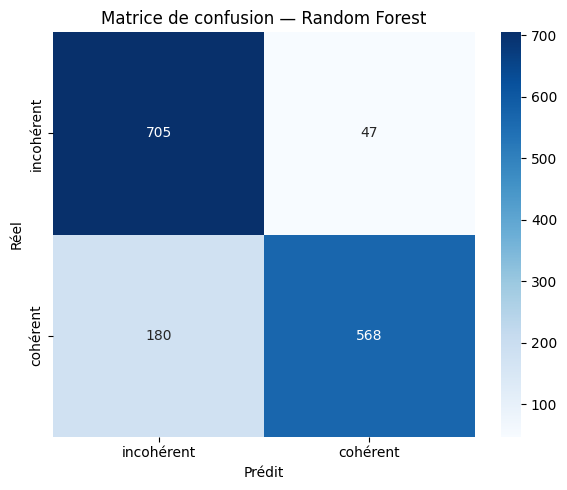

In [10]:
# Cell 10 — Évaluation finale sur le test set
y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("=" * 50)
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test F1       : {test_f1:.4f}")
print("=" * 50)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['incohérent','cohérent']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
plt.title(f'Matrice de confusion — {best_name}')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

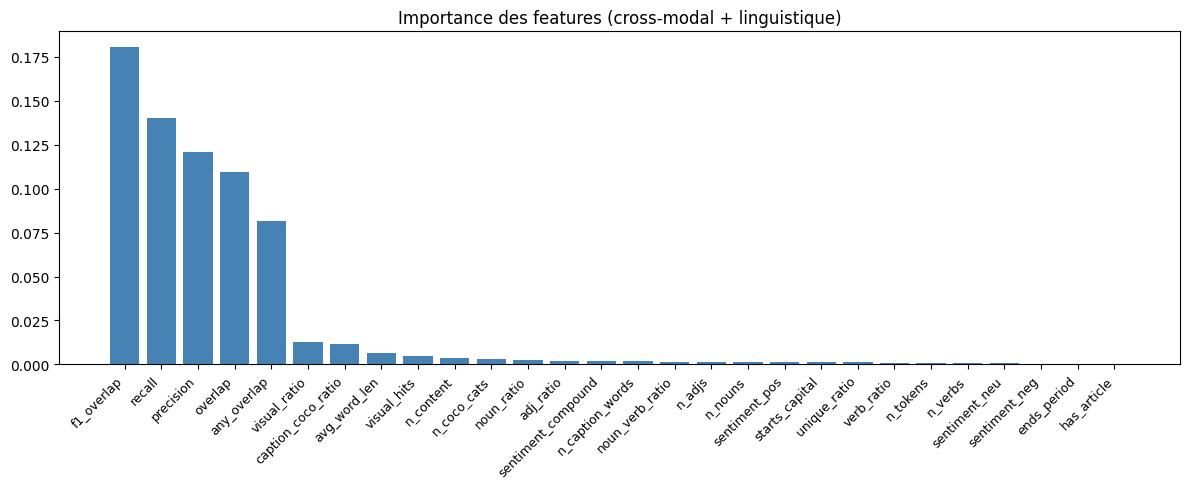


Top 5 features les plus importantes :
  f1_overlap                : 0.1805
  recall                    : 0.1405
  precision                 : 0.1207
  overlap                   : 0.1097
  any_overlap               : 0.0814


In [11]:
# Cell 11 — Importance des features cross-modales
feature_names = CROSS_NAMES + LING_NAMES + [f'tfidf_{i}' for i in range(T_train.shape[1])]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    print("Pas d'importance disponible pour ce modèle.")
    importances = None

if importances is not None:
    # Focus sur les features cross-modales + linguistiques (pas TF-IDF)
    n_hand = len(CROSS_NAMES) + len(LING_NAMES)
    hand_imp = importances[:n_hand]
    hand_names = CROSS_NAMES + LING_NAMES
    sorted_idx = np.argsort(hand_imp)[::-1]

    plt.figure(figsize=(12, 5))
    plt.bar(range(n_hand), hand_imp[sorted_idx], color='steelblue')
    plt.xticks(range(n_hand), [hand_names[i] for i in sorted_idx],
               rotation=45, ha='right', fontsize=9)
    plt.title('Importance des features (cross-modal + linguistique)')
    plt.tight_layout()
    plt.show()

    print("\nTop 5 features les plus importantes :")
    for i in sorted_idx[:5]:
        print(f"  {hand_names[i]:<25} : {hand_imp[i]:.4f}")


In [12]:
# Cell 12 — Sauvegarde + résultat final
import joblib
joblib.dump(best_model, 'coco_best_model.pkl')
joblib.dump(scaler,     'coco_scaler.pkl')
joblib.dump(tfidf,      'coco_tfidf.pkl')
joblib.dump(img2cats_all, 'coco_img2cats.pkl')

# Calculer ici si Cell 10 n'a pas tourné
y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print(f"{'='*50}")
print(f"  RÉSULTAT FINAL")
print(f"  Modèle      : {best_name}")
print(f"  Test Acc    : {test_acc:.4f}")
print(f"  Test F1     : {test_f1:.4f}")
print(f"{'='*50}")

  RÉSULTAT FINAL
  Modèle      : Random Forest
  Test Acc    : 0.8487
  Test F1     : 0.8335
